# Vẽ biểu đồ minh họa dữ liệu — BioAuth (ĐATN)

Notebook này **dùng lại chính các hàm trong `ve_bieu_do.py`** (không nhân đôi code), để xem từng biểu đồ inline rồi tự chọn lưu.

**Cách dùng:**
- Chạy ô *Thiết lập* một lần. Mặc định: `v.SHOW=True, v.SAVE=False` → chỉ **hiện**, không ghi file.
- Chạy từng ô bên dưới để xem biểu đồ tương ứng.
- Muốn **lưu** một biểu đồ: đặt `v.SAVE = True` rồi chạy lại đúng ô đó (PNG ghi vào thư mục `OUT`).

Toàn bộ logic phân đoạn dùng đúng hằng số của pipeline (`step2_preprocess`: `HZ`, `WINDOW_SIZE`, `STRIDE`, `MAX_GAP_SEC`).

In [14]:
# === Thiết lập ===
%matplotlib inline
import sys, importlib
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))   # để import được module trong ml_pipeline
import step2_preprocess as s
import ve_bieu_do as v
importlib.reload(v)

# Chế độ notebook: HIỆN biểu đồ, KHÔNG tự lưu
v.SHOW = True
v.SAVE = False

DATA_DIR = './data'
PROC_DIR = './processed'
OUT      = './plots'        # nơi lưu khi v.SAVE=True

print(f'HZ={s.HZ}  WINDOW_SIZE={s.WINDOW_SIZE}  STRIDE={s.STRIDE}  MAX_GAP_SEC={s.MAX_GAP_SEC} (= {s.MAX_GAP_SEC*1000:.0f} ms)')
print(f'SHOW={v.SHOW}  SAVE={v.SAVE}')

HZ=50  WINDOW_SIZE=200  STRIDE=20  MAX_GAP_SEC=0.1 (= 100 ms)
SHOW=True  SAVE=False


## A. Phân bố số cửa sổ sau tiền xử lý
Đọc `processed/<user>/*.npy`. Sinh `phanbo_theo_nguoi.png` và `phanbo_theo_cauhinh.png`.

Tổng cửa sổ — all: 163145 | walking: 54823


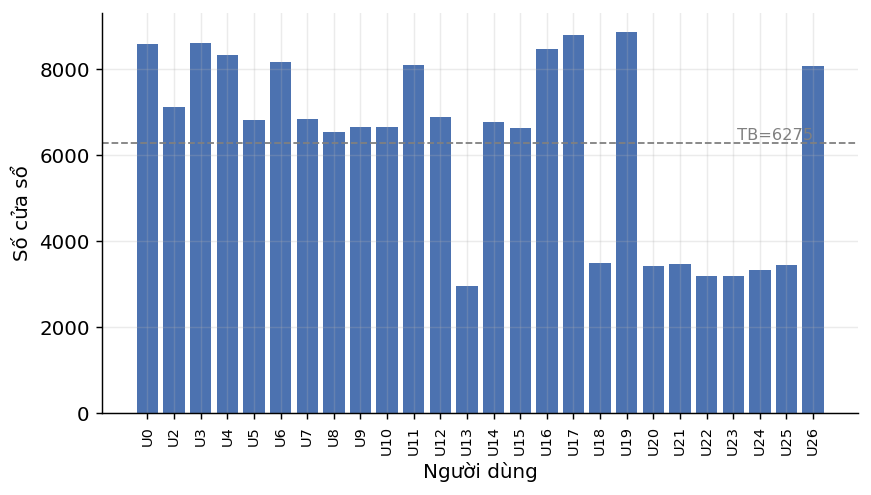

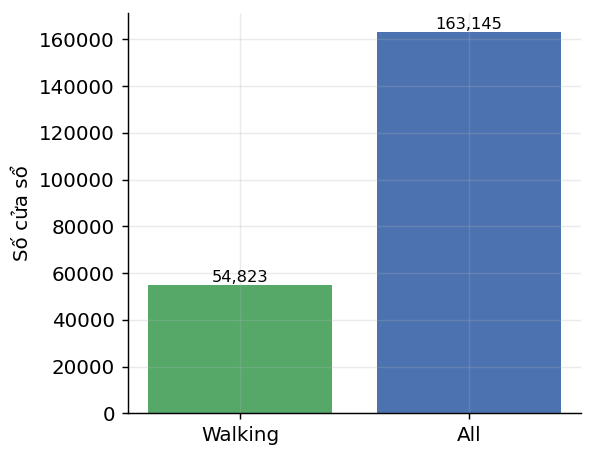

In [15]:
res = v._load_processed(PROC_DIR)
print('Tổng cửa sổ — all:', len(res['all']['y']), '| walking:', len(res['walking']['y']))
v.plot_phanbo(res, OUT)

## B. Tín hiệu thô: đi bộ (động) vs ngồi (tĩnh)
Đổi `user`, `session`, `seconds` tùy ý.

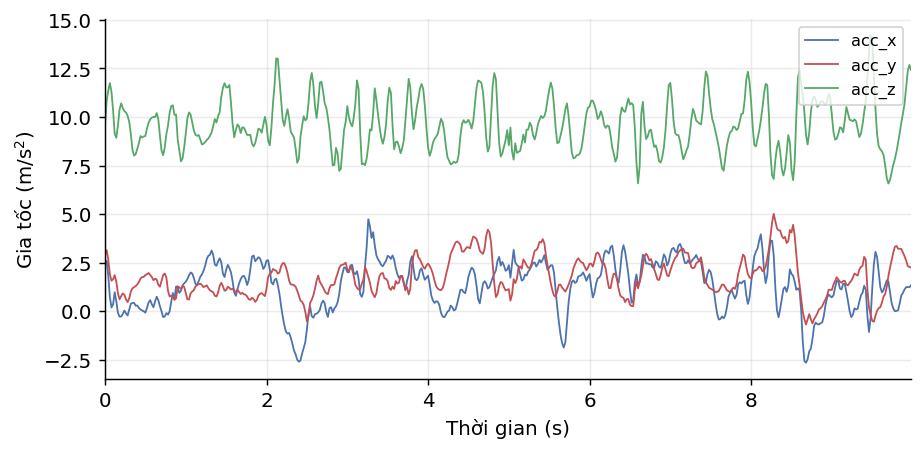

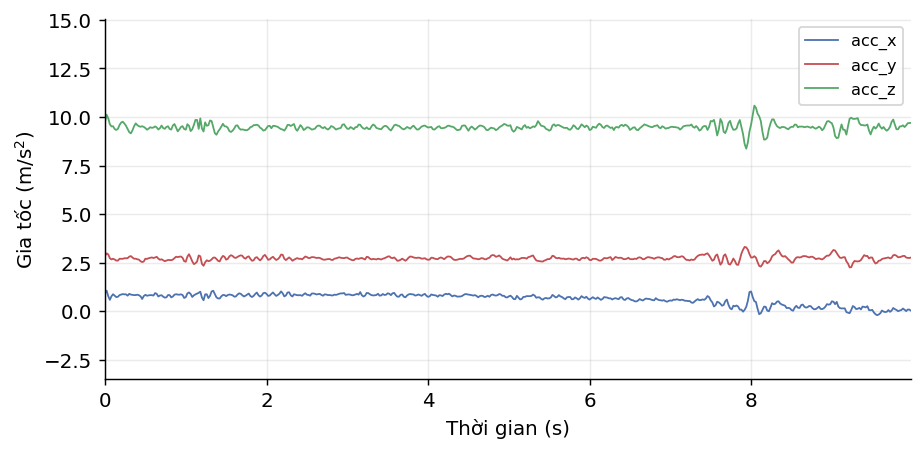

In [16]:
v.plot_tin_hieu_tho(DATA_DIR, OUT, user='user16', session='1', seconds=10)

## C. Cửa sổ trượt & chuẩn hóa z-score

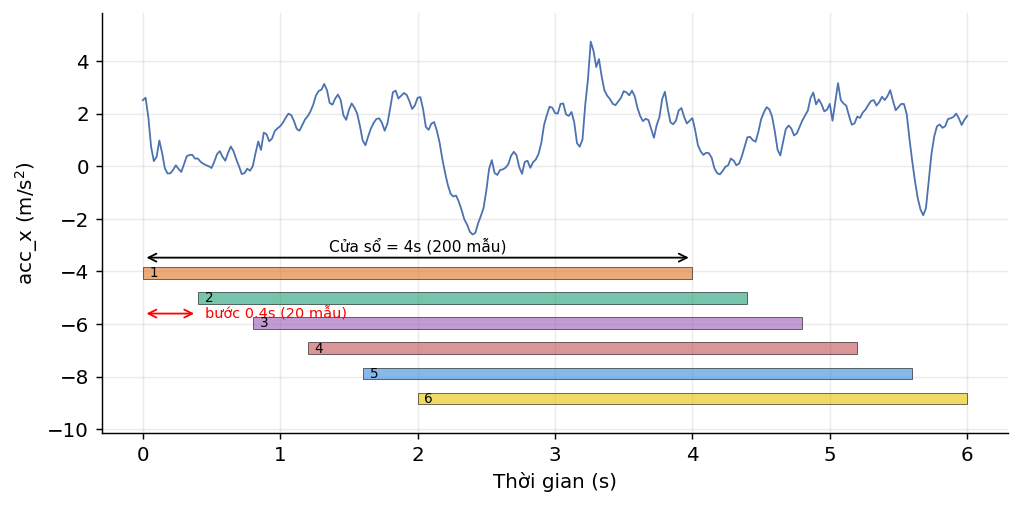

In [17]:
files = v._walking_files(DATA_DIR)
one   = [(u, f) for u, f in files if u == 'user16']   # biểu đồ 1 user

v.plot_cua_so_truot(one, OUT)      # minh họa cửa sổ trượt 200 mẫu, bước 20

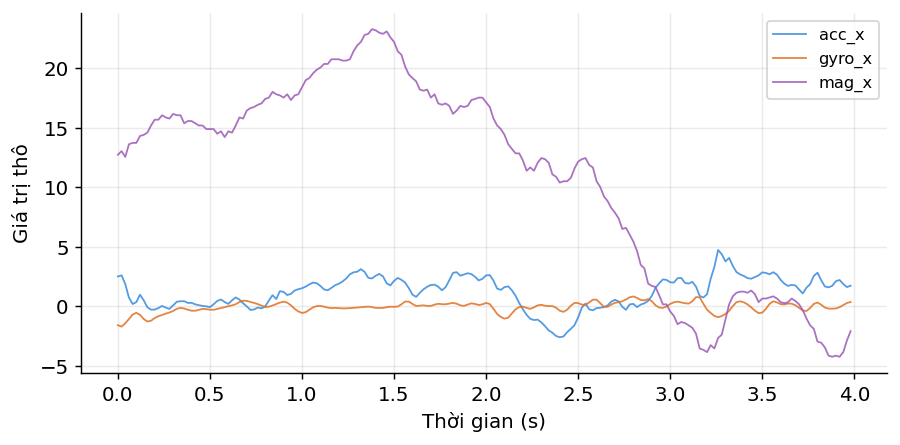

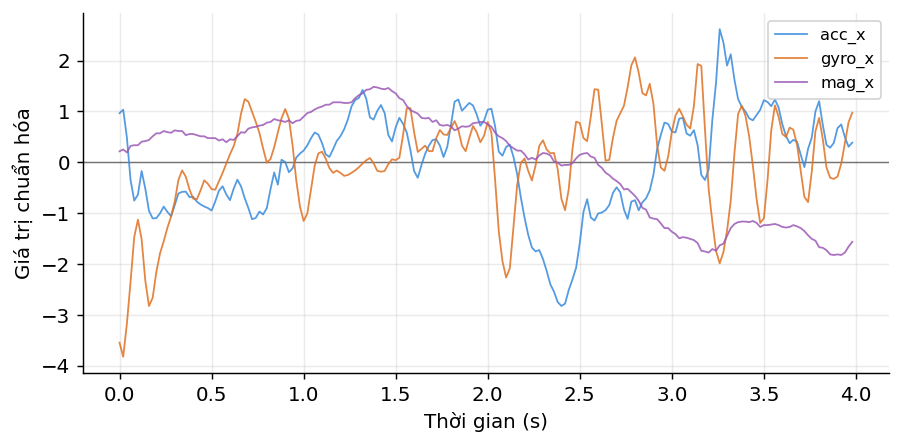

In [18]:
v.plot_window_zscore(one, OUT)     # một cửa sổ 4s: trước / sau z-score

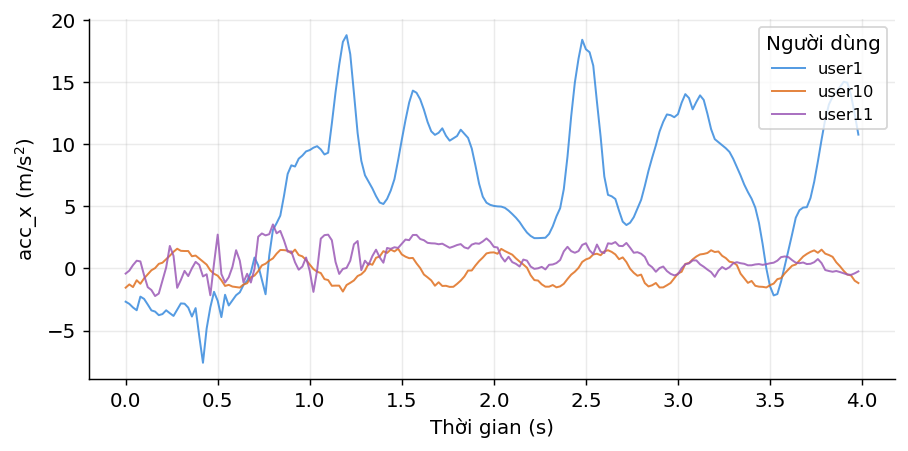

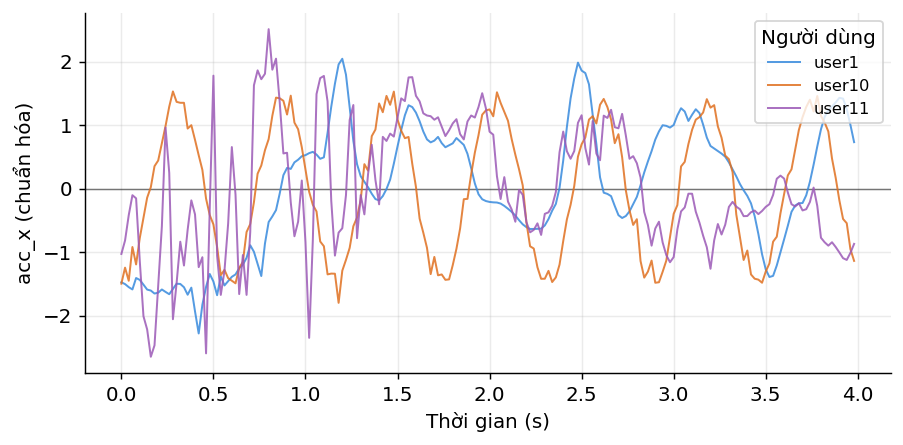

In [19]:
v.plot_zscore_users(files, OUT)    # acc_x của 3 người: trước / sau z-score

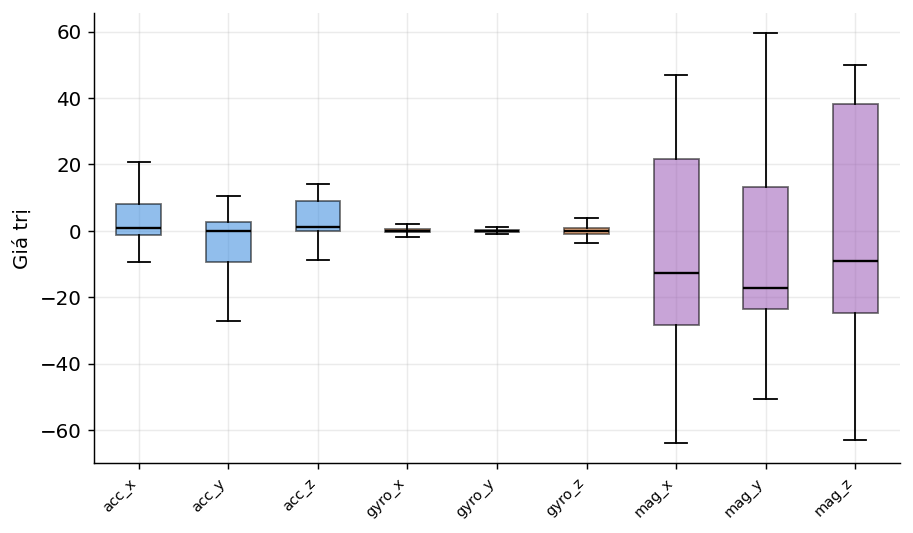

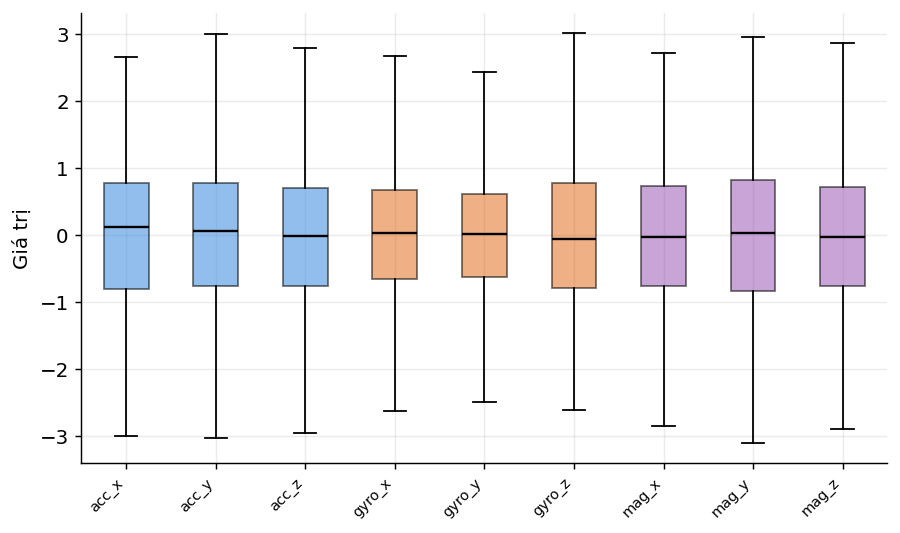

In [20]:
v.plot_scale_kenh(files, OUT)      # phân bố 9 kênh: trước / sau z-score

## D. Kiểm tra chất lượng & phân đoạn tín hiệu (mục 3.4.1)
In rõ cách suy ra: số mẫu, thời lượng, **số khoảng trống vượt ngưỡng**, độ dài từng đoạn và đoạn bị loại.
`zoom=None` → tự phóng to quanh đoạn bị loại; hoặc truyền `zoom=(t0, t1)` để phóng to khoảng giây tùy ý.


  Nguồn: data\user4\session_6\sitting_att1.csv
  • Số mẫu      = số dòng           = 9,810
  • Thời lượng  = (t_cuối - t_đầu)   = 194.7 s
  • Ngưỡng gián đoạn = 5 chu kỳ = 5/50Hz = 100 ms
  • Số khoảng trống > ngưỡng        = 7
      gap 1: tại mẫu #1791, dài 113 ms (~6 mẫu bị mất)
      gap 2: tại mẫu #1806, dài 178 ms (~9 mẫu bị mất)
      gap 3: tại mẫu #1808, dài 104 ms (~5 mẫu bị mất)
      gap 4: tại mẫu #3614, dài 103 ms (~5 mẫu bị mất)
      gap 5: tại mẫu #3737, dài 118 ms (~6 mẫu bị mất)
      gap 6: tại mẫu #3853, dài 104 ms (~5 mẫu bị mất)
      gap 7: tại mẫu #4160, dài 118 ms (~6 mẫu bị mất)
  • 8 đoạn liên tục, độ dài (mẫu) = [1791, 15, 2, 1806, 123, 116, 307, 5650]
  • Đoạn < 1 cửa sổ (200 mẫu) bị LOẠI = [15, 2, 123, 116]


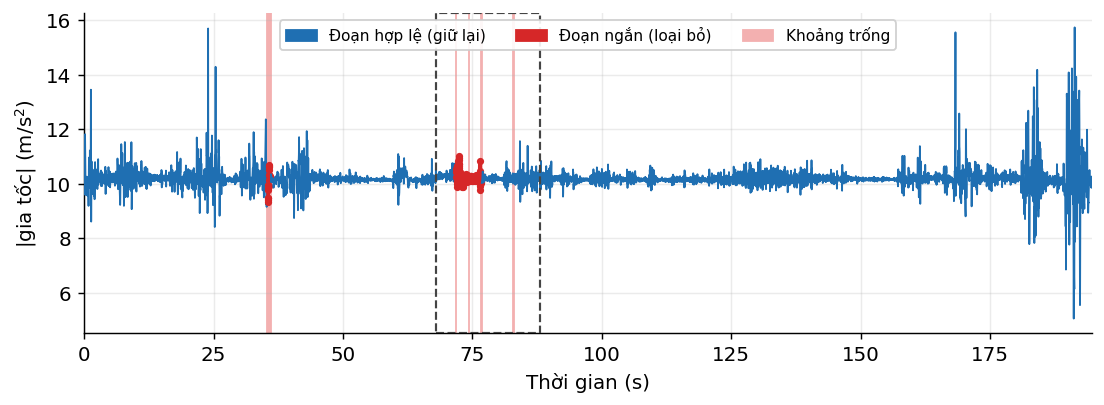

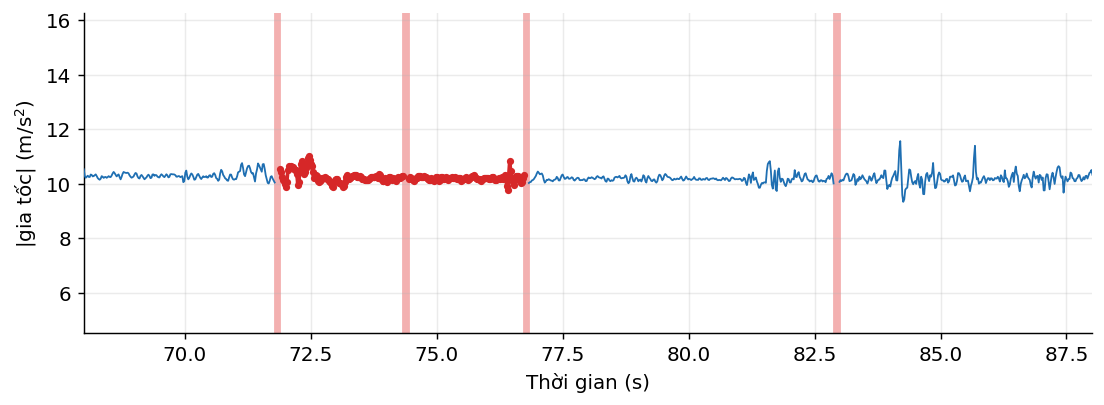

In [21]:
# File minh họa trong báo cáo (user4 / session_6 / sitting), phóng to vùng 68–88s
v.plot_phan_doan(DATA_DIR, OUT, user='user4', session='6', activity='sitting',
                 attempt='1', zoom=(68, 88))

## Lưu biểu đồ
Bật `v.SAVE = True` rồi **chạy lại đúng ô của biểu đồ muốn lưu**. PNG được ghi vào thư mục `OUT`.
Lưu xong nhớ đặt lại `v.SAVE = False` nếu chỉ muốn xem tiếp.

In [22]:
v.SAVE = True     # bật lưu
# v.SAVE = False  # tắt lưu (chỉ xem)
print('SAVE =', v.SAVE, '| thư mục lưu:', Path(OUT).resolve())

SAVE = True | thư mục lưu: F:\DATN\ml_pipeline\plots
